In [1]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../MERS/')

## 1. Set up the sky model and generate TOD

### 1.1 Time-stream specifications (JBO, zenith, night observations)

In [2]:
from astropy.coordinates import EarthLocation, AltAz, SkyCoord
from astropy.time import Time
import astropy.units as u
import healpy as hp

# === JBO site ===
lat = 53.23625  # degrees
lon = -2.30744  # degrees
location = EarthLocation(lat=lat*u.deg, lon=lon*u.deg)

# === Generate obs_time list（UTC）===
# From 2024-10-01 22:00 to 2024-10-02 05:00，every "delta_minutes" minute
start_time = Time('2024-10-01 22:00:00', scale='utc', location=location)
end_time   = Time('2024-10-02 05:00:00', scale='utc', location=location)
delta_minutes = 2

# Construct the time sequence
times = start_time + np.arange(0, (end_time - start_time).to_value('min') + delta_minutes, delta_minutes) * u.min

# === Calculate the corresponding LSTs ===
lst_array = times.sidereal_time('mean', longitude=lon*u.deg)

# === Constants ===
Nside = 256  # HEALPix resolution
lat = 53.23625  # JBO latitude in degrees

# === Step 1: LSTs → (RA, Dec) for zenith ===
# Dec of zenith = latitude
dec_zenith = lat * u.deg
ra_zeniths = lst_array.to(u.deg)  # LST is the RA of the zenith

# === Step 2: Convert to Galactic coordinates ===
skycoords_eq = SkyCoord(ra=ra_zeniths, dec=dec_zenith, frame='icrs')
skycoords_gal = skycoords_eq.galactic

# === Step 3: Convert to HEALPix pixel indices ===
# Use vector representation to feed into healpy
vecs = skycoords_gal.represent_as('cartesian').get_xyz().value  # shape: (3, N)
pix_indices = hp.vec2pix(Nside, vecs[0], vecs[1], vecs[2])

### 1.2 Generate sky TOD

In [ ]:
from beam_model import Chromatic_Sinc_Squared, Achromatic_Gaussian_Beam, Achromatic_Sinc_Squared

# Set up the frequency list: [50, 200] MHz
freq_list = np.linspace(50., 200., 101)
Nfreq = len(freq_list)

Gaussian_beam = Achromatic_Gaussian_Beam(60, Nfreq, nside=Nside)
Gaussian_beam.get_beam_l()
Gaussian_ach_bl0 = Gaussian_beam.bl_list
Gaussian_ach_bl = [ B_l0 * np.sqrt(4 * np.pi / (2 * np.arange(len(B_l0)) + 1)) for B_l0 in Gaussian_ach_bl0 ]

Sinc_ach_beam = Achromatic_Sinc_Squared(len(freq_list), fwhm_deg=10, nside=Nside)
Sinc_ach_beam.get_beam_l()
Sinc_ach_bl0 = Sinc_ach_beam.bl_list
Sinc_ach_bl = [ B_l0 * np.sqrt(4 * np.pi / (2 * np.arange(len(B_l0)) + 1)) for B_l0 in Sinc_ach_bl0 ]

def fwhm_function(nu_mhz, params):
    return params["K"] / nu_mhz

fwhm_func_params = {"K": 4000}

Sinc_ch_beam = Chromatic_Sinc_Squared(freq_list, fwhm_function, fwhm_func_params, nside=Nside)
Sinc_ch_beam.get_beam_l()
Sinc_ch_bl0 = Sinc_ch_beam.bl_list
Sinc_ch_bl = [ B_l0 * np.sqrt(4 * np.pi / (2 * np.arange(len(B_l0)) + 1)) for B_l0 in Sinc_ch_bl0 ]


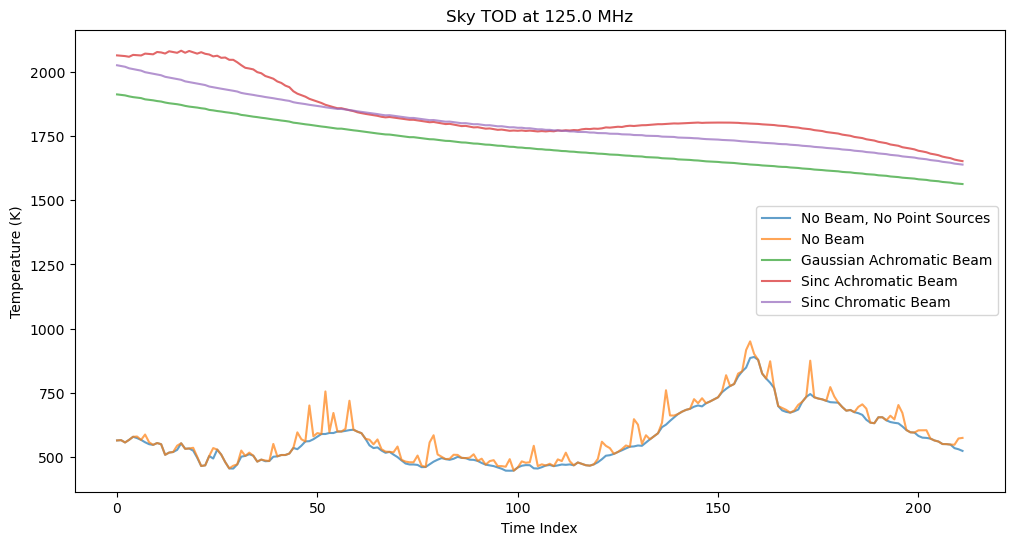

In [5]:
from fg_model import CNN_PL_sky, ptsrc_powerlaw
# Point source model initialization
ptsrc_model = ptsrc_powerlaw(nside=Nside)

def sky_TOD(beam_window=None, add_ptsrc=True):
    """
    Generate sky time-ordered data (TOD) for the given beam window function.
    
    Parameters:
    beam_window: list of ndarray
        Beam window functions for each frequency channel. Each element should be an array of shape (lmax+1,).
        If None, no beam is applied.
    add_ptsrc: bool
        Whether to include point sources in the sky model.
    
    Returns:
    sky_TOD: ndarray
        Time-ordered data of the sky, shape (Ntime, Nfreq).
    """

    # Diffuse + ptsrc sky model
    diffuse_sky, pivot_specidx_map = CNN_PL_sky(freq_list, beam_transfer=beam_window, nside=Nside, return_spec_index=True)
    
    if add_ptsrc:
        ptsrc_sky = ptsrc_model(freq_list, beam_transfer=beam_window)
        combined_sky = diffuse_sky + ptsrc_sky
    else:
        combined_sky = diffuse_sky

    sky_TOD = combined_sky[pix_indices, :]  # shape: (Ntime, Nfreq)
    piv_spec_ind_TOD = pivot_specidx_map[pix_indices]  
    
    return sky_TOD, piv_spec_ind_TOD

sky_TOD_no_beam_no_ptsrc, pivot_specind_TOD = sky_TOD(beam_window=None, add_ptsrc=False)
sky_TOD_no_beam, _ = sky_TOD(beam_window=None)
sky_TOD_Gaussian_ach, _ = sky_TOD(beam_window=Gaussian_ach_bl)
sky_TOD_Sinc_ach, _ = sky_TOD(beam_window=Sinc_ach_bl)
sky_TOD_Sinc_ch, _ = sky_TOD(beam_window=Sinc_ch_bl)

# Visualize the TODs at a specific frequency channel
freq_channel = 50  # Index of the frequency channel to visualize
plt.figure(figsize=(12, 6))

plt.plot(sky_TOD_no_beam_no_ptsrc[:, freq_channel], label='No Beam, No Point Sources', alpha=0.7)
plt.plot(sky_TOD_no_beam[:, freq_channel], label='No Beam', alpha=0.7)
plt.plot(sky_TOD_Gaussian_ach[:, freq_channel], label='Gaussian Achromatic Beam', alpha=0.7)
plt.plot(sky_TOD_Sinc_ach[:, freq_channel], label='Sinc Achromatic Beam', alpha=0.7)
plt.plot(sky_TOD_Sinc_ch[:, freq_channel], label='Sinc Chromatic Beam', alpha=0.7)
plt.xlabel('Time Index')
plt.ylabel('Temperature (K)')
plt.title(f'Sky TOD at {freq_list[freq_channel]:.1f} MHz')
plt.legend()
plt.show()  

## 2. Fitting Sky TODs

In [6]:
from SEDfitting import fit_fg_cube
max_order = 6

nBnP_coeffs, nBnP_loss, nBnP_resi = fit_fg_cube(
    sky_TOD_no_beam_no_ptsrc, 
    pivot_specind_TOD, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=None, 
    BCF=None
)

nB_coeffs, nB_loss, nB_resi = fit_fg_cube(
    sky_TOD_no_beam, 
    pivot_specind_TOD, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=None, 
    BCF=None
)

achGau_coeffs, achGau_loss, achGau_resi = fit_fg_cube(
    sky_TOD_Gaussian_ach, 
    pivot_specind_TOD, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=None, 
    BCF=None
)

achSinc_coeffs, achSinc_loss, achSinc_resi = fit_fg_cube(
    sky_TOD_Sinc_ach, 
    pivot_specind_TOD, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=None, 
    BCF=None
)

chSinc_coeffs, chSinc_loss, chSinc_resi = fit_fg_cube(
    sky_TOD_Sinc_ch, 
    pivot_specind_TOD, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=None, 
    BCF=None
)

In [7]:
nBnP_loss.shape

(212,)

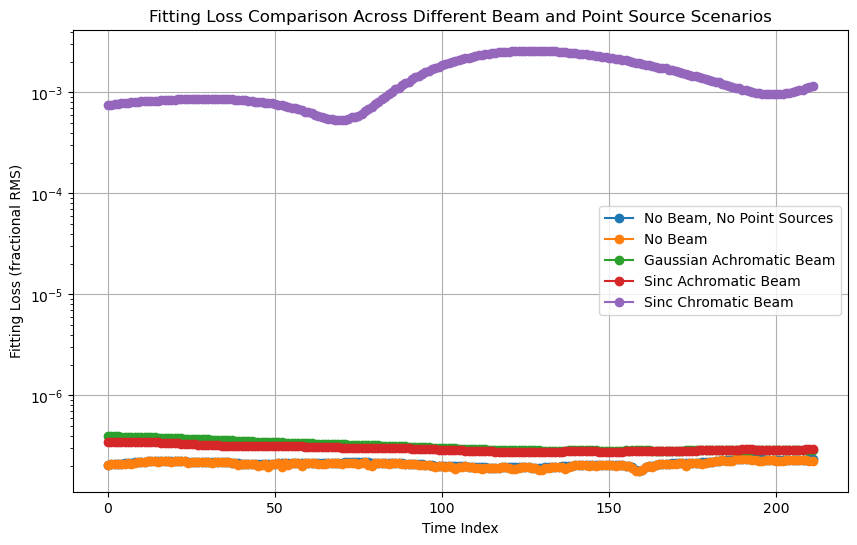

In [10]:
# Visualize the fitting loss
plt.figure(figsize=(10, 6))
plt.plot(nBnP_loss, label='No Beam, No Point Sources', marker='o')
plt.plot(nB_loss, label='No Beam', marker='o')
plt.plot(achGau_loss, label='Gaussian Achromatic Beam', marker='o')
plt.plot(achSinc_loss, label='Sinc Achromatic Beam', marker='o')
plt.plot(chSinc_loss, label='Sinc Chromatic Beam', marker='o')
plt.xlabel('Time Index')
plt.ylabel('Fitting Loss (fractional RMS)')
plt.yscale('log')
plt.title('Fitting Loss Comparison Across Different Beam and Point Source Scenarios')
plt.legend()
plt.grid()
plt.show()